<a href="https://colab.research.google.com/github/devunisathish/NASSCOM-MODULE-1/blob/main/DAY2/DAY2EXERCISEU6_%E2%80%94_Probability_%26_Statistics_(Part_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**U6 — Probability & Statistics (Part 1):** Lab
Descriptive Statistics — central tendency · spread · shape · correlation · summarizing data

**Day 2 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2**

**objectives**
By the end of this lab you will be able to:

Tell categorical and numerical variables apart and pick the right statistic

Compute measures of central tendency: mean, median and mode

Compute measures of spread: range, variance, standard deviation and IQR

Describe the shape of a distribution with the five-number summary and a box plot

Measure how variables relate with correlation, and summarise a whole dataset at once

how to use this lab
Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

**LAB EXERCISE cells** (marked 🧪) — your turn. Replace each # YOUR CODE HERE with working code.

Run cells with Shift + Enter. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**1. Types of data & variables**

In [2]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


LAB EXERCISE 1 — Classify the columns
Print the list of numerical columns and the list of categorical columns.
For a numerical column (e.g. tip), print its mean.
For a categorical column (e.g. sex), print its value counts.

In [4]:
# 1. Numerical vs categorical columns
print('Numerical  :', numerical)
print('Categorical:', categorical)

# 2. Mean of a numerical column (tip)
print('Mean tip:', round(df['tip'].mean(), 2))

# 3. Value counts of a categorical column (sex)
print('Sex value counts:')
print(df['sex'].value_counts())

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean tip: 3.0
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


**2. Measures of central tendency**

In [5]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


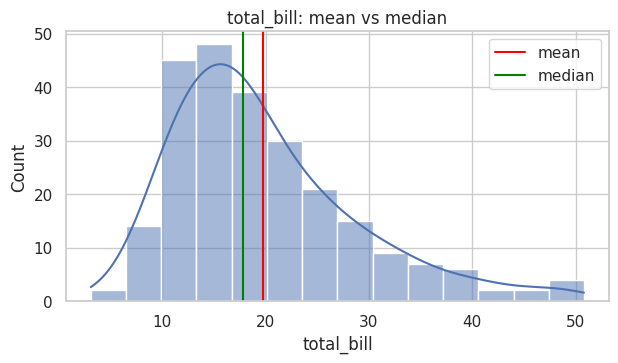

In [6]:
# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

LAB EXERCISE 2 — Central tendency
For the tip column:

Print its mean, median and mode.
Is it right-skewed? Check whether mean > median.
Plot a histogram of tip with vertical lines at the mean and median.

Mean   : 3.0
Median : 2.9
Mode   : 2.0
mean > median ? True -> right-skewed


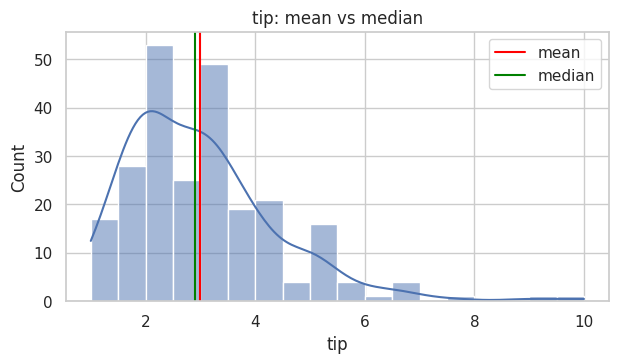

In [7]:
tip = df['tip']

# 1. mean, median, mode
print('Mean   :', round(tip.mean(), 2))
print('Median :', round(tip.median(), 2))
print('Mode   :', round(tip.mode()[0], 2))

# 2. mean > median ?
print('mean > median ?', tip.mean() > tip.median(), '-> right-skewed')

# 3. histogram with mean & median lines (reuse the pattern from 2B)
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(),   color='red',   label='mean')
plt.axvline(tip.median(), color='green', label='median')
plt.legend(); plt.title('tip: mean vs median'); plt.show()

3. Measures of spread (dispersion)

In [8]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 47.74
Var   : 79.25
Std   : 8.9


In [9]:
# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


WII DO AFTER WARDS THIS IS DAY 2 U6 AND IT WAS AT LAB EXERCISE 3
